## Project 2: Greeks, Risk Sensitivity & Implied Volatility

In [3]:
import numpy as np
import scipy.stats as si
from scipy.optimize import brentq
import matplotlib.pyplot as plt
!pip install yfinance --quiet
import yfinance as yf

## Core Black-Scholes + All Greeks

In [4]:
def d1d2(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def black_scholes_call(S, K, T, r, sigma):
    d1, d2 = d1d2(S, K, T, r, sigma)
    return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)

def black_scholes_put(S, K, T, r, sigma):
    d1, d2 = d1d2(S, K, T, r, sigma)
    return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

# DELTA

def delta_call(S, K, T, r, sigma):
    d1, _ = d1d2(S, K, T, r, sigma)
    return si.norm.cdf(d1)

def delta_put(S, K, T, r, sigma):
    d1, _ = d1d2(S, K, T, r, sigma)
    return si.norm.cdf(d1) - 1

# GAMMA

def gamma(S, K, T, r, sigma):
    d1, _ = d1d2(S, K, T, r, sigma)
    return si.norm.pdf(d1) / (S * sigma * np.sqrt(T))

# VEGA

def vega(S, K, T, r, sigma):
    d1, _ = d1d2(S, K, T, r, sigma)
    return S * si.norm.pdf(d1) * np.sqrt(T) * 0.01  # per 1% vol

# THETA

def theta_call(S, K, T, r, sigma):
    d1, d2 = d1d2(S, K, T, r, sigma)
    term1 = -(S * si.norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    term2 = -r * K * np.exp(-r * T) * si.norm.cdf(d2)
    return (term1 + term2) / 365  # daily theta

def theta_put(S, K, T, r, sigma):
    d1, d2 = d1d2(S, K, T, r, sigma)
    term1 = -(S * si.norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    term2 = r * K * np.exp(-r * T) * si.norm.cdf(-d2)
    return (term1 + term2) / 365

print("✅ All Greeks functions defined: Delta, Gamma, Vega, Theta")

✅ All Greeks functions defined: Delta, Gamma, Vega, Theta


In [5]:
ticker = "AAPL"
data = yf.Ticker(ticker)
S = data.history(period="1d")['Close'].iloc[0]
hist = data.history(period="1y")['Close']
sigma = np.std(hist.pct_change().dropna()) * np.sqrt(252)

K = round(S)
T = 30 / 365
r = 0.05

print(f"{ticker} | S=${S:.2f} | K=${K} | σ={sigma:.2%} | T=30d | r={r:.0%}\n")
print("=" * 45)
print(f"{'Greek':<12} {'Call':>10} {'Put':>10}")
print("-" * 45)
print(f"{'Price':<12} {'$'+f'{black_scholes_call(S,K,T,r,sigma):.2f}':>10} {'$'+f'{black_scholes_put(S,K,T,r,sigma):.2f}':>10}")
print(f"{'Delta':<12} {delta_call(S,K,T,r,sigma):>10.4f} {delta_put(S,K,T,r,sigma):>10.4f}")
print(f"{'Gamma':<12} {gamma(S,K,T,r,sigma):>10.4f} {gamma(S,K,T,r,sigma):>10.4f}")
print(f"{'Vega(1%)':<12} {'$'+f'{vega(S,K,T,r,sigma):.4f}':>10} {'$'+f'{vega(S,K,T,r,sigma):.4f}':>10}")
print(f"{'Theta/day':<12} {'$'+f'{theta_call(S,K,T,r,sigma):.4f}':>10} {'$'+f'{theta_put(S,K,T,r,sigma):.4f}':>10}")
print("=" * 45)

AAPL | S=$254.82 | K=$255 | σ=31.83% | T=30d | r=5%

Greek              Call        Put
---------------------------------------------
Price             $9.70      $8.83
Delta            0.5330    -0.4670
Gamma            0.0171     0.0171
Vega(1%)        $0.2904    $0.2904
Theta/day      $-0.1714   $-0.1366


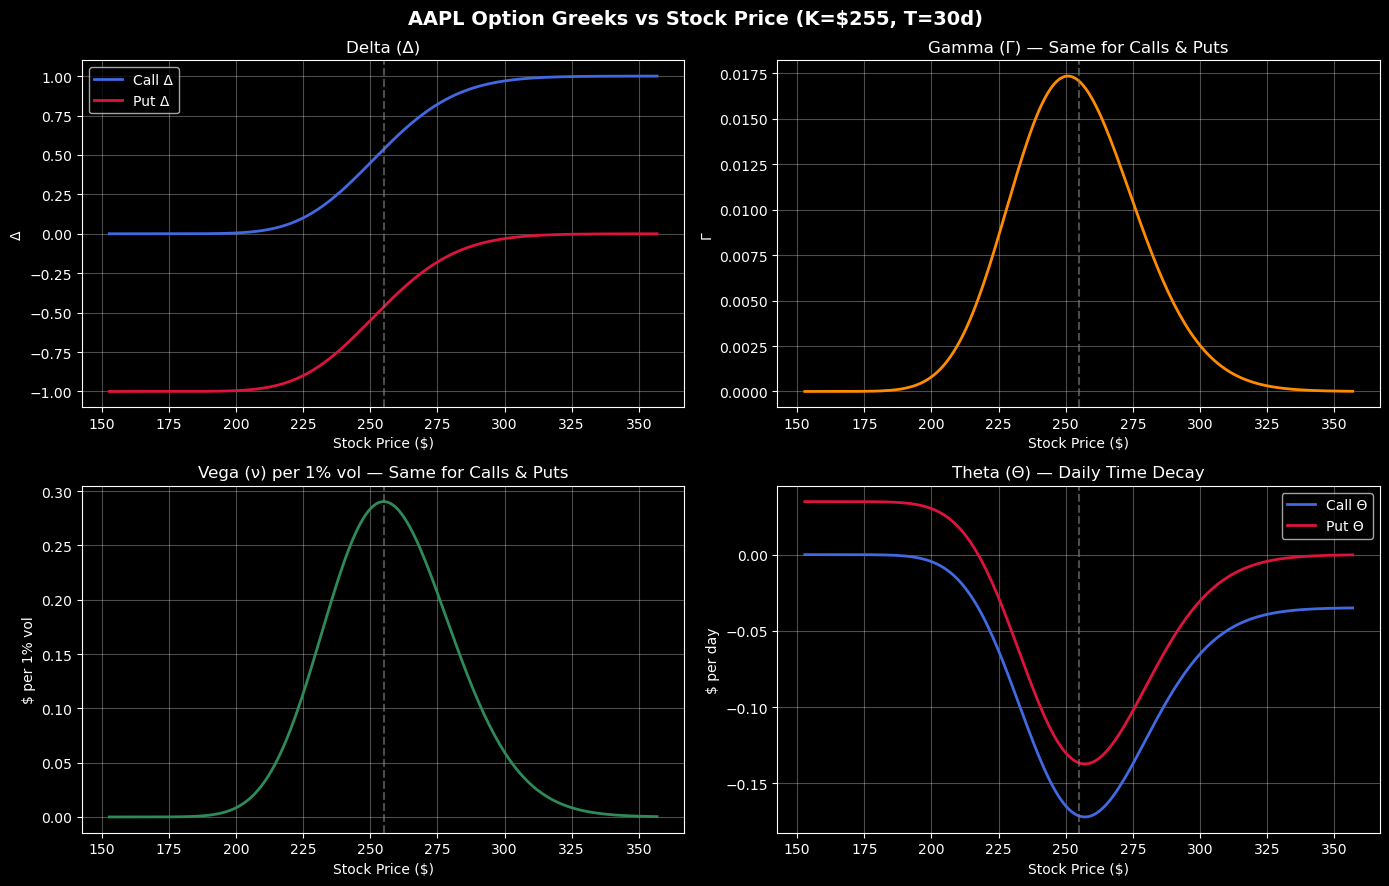

In [11]:
S_range = np.linspace(S * 0.6, S * 1.4, 200)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"{ticker} Option Greeks vs Stock Price (K=${K}, T=30d)", fontsize=14, fontweight='bold')

# Delta
axes[0,0].plot(S_range, [delta_call(s,K,T,r,sigma) for s in S_range], 'royalblue', lw=2, label='Call Δ')
axes[0,0].plot(S_range, [delta_put(s,K,T,r,sigma)  for s in S_range], 'crimson',   lw=2, label='Put Δ')
axes[0,0].axvline(K, color='gray', linestyle='--', alpha=0.6)
axes[0,0].set_title('Delta (Δ)')
axes[0,0].set_ylabel('Δ'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Gamma
axes[0,1].plot(S_range, [gamma(s,K,T,r,sigma) for s in S_range], 'darkorange', lw=2)
axes[0,1].axvline(K, color='gray', linestyle='--', alpha=0.6)
axes[0,1].set_title('Gamma (Γ) — Same for Calls & Puts')
axes[0,1].set_ylabel('Γ'); axes[0,1].grid(True, alpha=0.3)

# Vega
axes[1,0].plot(S_range, [vega(s,K,T,r,sigma) for s in S_range], 'seagreen', lw=2)
axes[1,0].axvline(K, color='gray', linestyle='--', alpha=0.6)
axes[1,0].set_title('Vega (ν) per 1% vol — Same for Calls & Puts')
axes[1,0].set_ylabel('$ per 1% vol'); axes[1,0].grid(True, alpha=0.3)

# Theta
axes[1,1].plot(S_range, [theta_call(s,K,T,r,sigma) for s in S_range], 'royalblue', lw=2, label='Call Θ')
axes[1,1].plot(S_range, [theta_put(s,K,T,r,sigma)  for s in S_range], 'crimson',   lw=2, label='Put Θ')
axes[1,1].axvline(K, color='gray', linestyle='--', alpha=0.6)
axes[1,1].set_title('Theta (Θ) — Daily Time Decay')
axes[1,1].set_ylabel('$ per day'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Stock Price ($)')

plt.tight_layout()
plt.show()

## 4. Implied Volatility Solver
**IV is the market's implied σ — backed out from the observed market option price using numerical root-finding (Brent's method).**

In [7]:
def implied_vol_call(market_price, S, K, T, r, tol=1e-6):
    """
    Solve for implied volatility of a call option.
    Uses Brent's method — fast and robust bracketing root-finder.
    Returns NaN if no solution found (deep ITM/OTM edge cases).
    """
    intrinsic = max(S - K * np.exp(-r * T), 0)
    if market_price < intrinsic:
        return np.nan
    try:
        iv = brentq(
            lambda sigma: black_scholes_call(S, K, T, r, sigma) - market_price,
            1e-6, 10.0, xtol=tol
        )
        return iv
    except ValueError:
        return np.nan

def implied_vol_put(market_price, S, K, T, r, tol=1e-6):
    """Solve for implied volatility of a put option."""
    intrinsic = max(K * np.exp(-r * T) - S, 0)
    if market_price < intrinsic:
        return np.nan
    try:
        iv = brentq(
            lambda sigma: black_scholes_put(S, K, T, r, sigma) - market_price,
            1e-6, 10.0, xtol=tol
        )
        return iv
    except ValueError:
        return np.nan

# Sanity check
test_sigma = 0.30
test_price = black_scholes_call(S, K, T, r, test_sigma)
recovered  = implied_vol_call(test_price, S, K, T, r)
print(f"Input σ = {test_sigma:.2%} → BS Price = ${test_price:.4f} → Recovered IV = {recovered:.2%}")
print(f"Round-trip error: {abs(test_sigma - recovered):.2e} ✅" if abs(test_sigma - recovered) < 1e-5 else "❌ Error too large")

Input σ = 30.00% → BS Price = $9.1656 → Recovered IV = 30.00%
Round-trip error: 1.34e-07 ✅


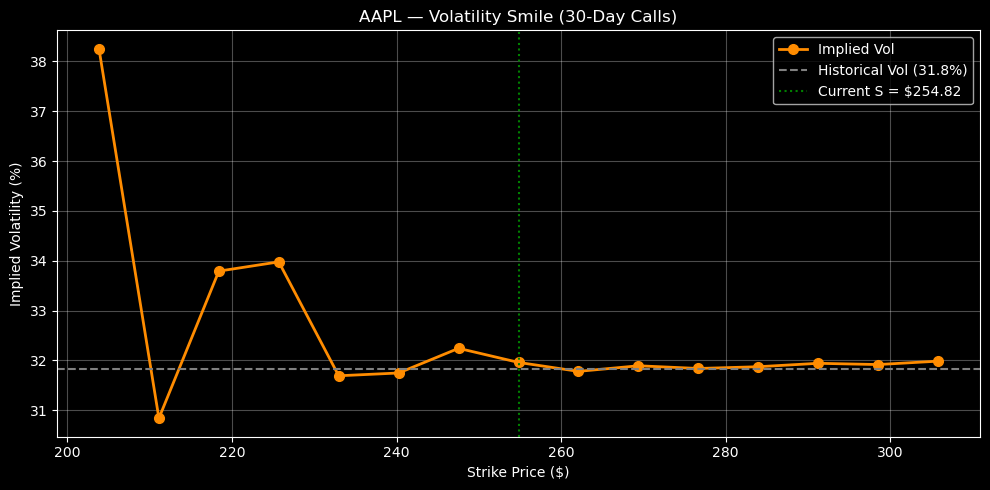

In [8]:
np.random.seed(42)
strikes = np.linspace(S * 0.80, S * 1.20, 15)

# Simulate market prices
smile_vol = sigma + 0.05 * ((strikes - S) / S)**2  # parabolic smile
market_prices = [black_scholes_call(S, k, T, r, v) * (1 + np.random.normal(0, 0.005))
                 for k, v in zip(strikes, smile_vol)]

# Recover IV from each market price
ivs = [implied_vol_call(mp, S, k, T, r) for mp, k in zip(market_prices, strikes)]

plt.figure(figsize=(10, 5))
plt.plot(strikes, [iv * 100 for iv in ivs if not np.isnan(iv)],
         'o-', color='darkorange', lw=2, markersize=7, label='Implied Vol')
plt.axhline(sigma * 100, color='gray', linestyle='--', label=f'Historical Vol ({sigma:.1%})')
plt.axvline(S, color='green', linestyle=':', label=f'Current S = ${S:.2f}')
plt.xlabel('Strike Price ($)')
plt.ylabel('Implied Volatility (%)')
plt.title(f'{ticker} — Volatility Smile (30-Day Calls)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

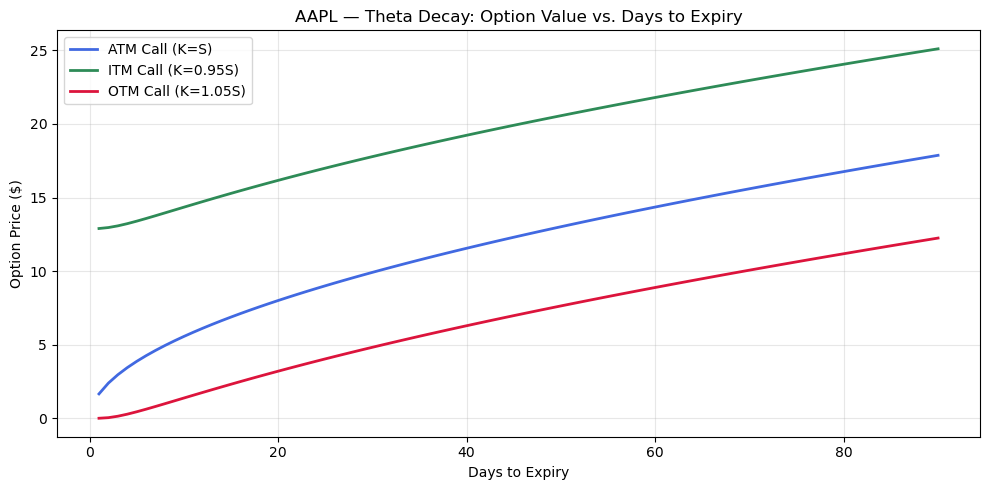

In [7]:
days_left = np.arange(1, 91)[::-1]  # 90 down to 1
T_range = days_left / 365

atm_call  = [black_scholes_call(S, K, t, r, sigma) for t in T_range]
itm_call  = [black_scholes_call(S, K * 0.95, t, r, sigma) for t in T_range]
otm_call  = [black_scholes_call(S, K * 1.05, t, r, sigma) for t in T_range]

plt.figure(figsize=(10, 5))
plt.plot(days_left, atm_call, 'royalblue', lw=2, label='ATM Call (K=S)')
plt.plot(days_left, itm_call, 'seagreen',  lw=2, label='ITM Call (K=0.95S)')
plt.plot(days_left, otm_call, 'crimson',   lw=2, label='OTM Call (K=1.05S)')
plt.xlabel('Days to Expiry')
plt.ylabel('Option Price ($)')
plt.title(f'{ticker} — Theta Decay: Option Value vs. Days to Expiry')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()